In [129]:
import pandas as pd
import numpy as np

In [130]:
train_data = pd.read_csv("../../datasets/spaceship-titanic/train.csv")

In [131]:
train_data.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [132]:
test_data = pd.read_csv("../../datasets/spaceship-titanic/test.csv")
test_data.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [133]:
train_data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [134]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [135]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


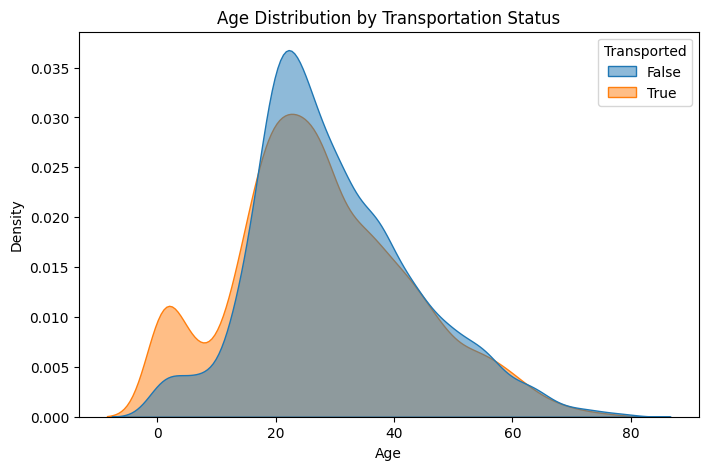

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
# KDE plot splits the numeric age by the categorical target
sns.kdeplot(data=train_data, x='Age', hue='Transported', fill=True, common_norm=False, alpha=0.5)

plt.title('Age Distribution by Transportation Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

In [137]:
# X = train_data.drop(["PassengerId", "Cabin", ])
# y = train_data["Transported"]

train_data.select_dtypes(include="number")

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...
8688,41.0,0.0,6819.0,0.0,1643.0,74.0
8689,18.0,0.0,0.0,0.0,0.0,0.0
8690,26.0,0.0,0.0,1872.0,1.0,0.0
8691,32.0,0.0,1049.0,0.0,353.0,3235.0


In [138]:
train_data["CryoSleep"] = train_data["CryoSleep"].fillna(False)
train_data["HomePlanet"] = train_data["HomePlanet"].fillna("Earth")
train_data = pd.get_dummies(train_data, columns = ["HomePlanet", "CryoSleep", "Destination", "VIP"], drop_first=True)
# train_data.drop(["Name", "Cabin", "PassengerId"], axis = 1)

C:\Users\Sharanya Nagar\AppData\Local\Temp\ipykernel_22360\2909574618.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data["CryoSleep"] = train_data["CryoSleep"].fillna(False)


In [139]:
# train_data = train_data.drop(["Name"], axis = 1)

In [140]:
train_data.head(5)

,PassengerId,Cabin,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,0001_01,B/0/P,39.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,True,False,False,False,True,False
1,0002_01,F/0/S,24.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,False,False,False,False,True,False
2,0003_01,A/0/S,58.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,True,False,False,False,True,True
3,0003_02,A/0/S,33.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,True,False,False,False,True,False
4,0004_01,F/1/S,16.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,False,False,False,False,True,False


In [141]:
train_data.isnull().sum()

PassengerId                    0
Cabin                        199
Age                          179
RoomService                  181
FoodCourt                    183
ShoppingMall                 208
Spa                          183
VRDeck                       188
Name                         200
Transported                    0
HomePlanet_Europa              0
HomePlanet_Mars                0
CryoSleep_True                 0
Destination_PSO J318.5-22      0
Destination_TRAPPIST-1e        0
VIP_True                       0
dtype: int64

In [142]:
train_data[['Deck','CabinNum','Side']] = train_data['Cabin'].str.split('/', expand=True)
train_data['CabinNum'] = pd.to_numeric(train_data['CabinNum'], errors='coerce')
# train_data.drop(['Cabin'], axis=1, inplace=True)

In [143]:
train_data['Group']     = train_data['PassengerId'].str[:4]   # "0003"
train_data['GroupSize'] = train_data.groupby('Group')['Group'].transform('count')
train_data['IsAlone']   = (train_data['GroupSize'] == 1).astype(int)

spend = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
train_data['TotalSpend'] = train_data[spend].sum(axis=1)
train_data['HasSpent']   = (train_data['TotalSpend'] > 0).astype(int)
train_data['SpendLog']   = np.log1p(train_data['TotalSpend'])  # de-skew the heavy tail

train_data.drop(['PassengerId','Name','Cabin','Group'], axis=1, inplace=True)

In [144]:
train_data["RoomService"] = train_data["RoomService"].fillna(train_data["RoomService"].mean())
train_data["FoodCourt"] = train_data["FoodCourt"].fillna(train_data["FoodCourt"].mean())
train_data["ShoppingMall"] = train_data["ShoppingMall"].fillna(train_data["ShoppingMall"].mean())
train_data["Spa"] = train_data["Spa"].fillna(train_data["Spa"].mean())
train_data["VRDeck"] = train_data["VRDeck"].fillna(train_data["VRDeck"].mean())

In [145]:
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].mean())
train_data["CabinNum"] = train_data["CabinNum"].fillna(train_data["CabinNum"].mean())

In [146]:
train_data.isnull().sum()

Age                            0
RoomService                    0
FoodCourt                      0
ShoppingMall                   0
Spa                            0
VRDeck                         0
Transported                    0
HomePlanet_Europa              0
HomePlanet_Mars                0
CryoSleep_True                 0
Destination_PSO J318.5-22      0
Destination_TRAPPIST-1e        0
VIP_True                       0
Deck                         199
CabinNum                       0
Side                         199
GroupSize                      0
IsAlone                        0
TotalSpend                     0
HasSpent                       0
SpendLog                       0
dtype: int64

In [147]:
train_data["Deck"] = train_data["Deck"].fillna(False)
train_data["Side"] = train_data["Side"].fillna(False)
train_data = pd.get_dummies(data = train_data, columns = ["Deck", "Side"], drop_first=True)

In [148]:
X = train_data.drop("Transported", axis = 1)
y = train_data["Transported"]

In [149]:
from sklearn.model_selection import train_test_split

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 16)

In [151]:
X_train.select_dtypes(include="object")

""
1874
6153
4664
4489
3228
...
635
1345
581
2169


In [152]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns, index = X_train.index)
X_test = pd.DataFrame(scaler.fit_transform(X_test), columns = X_test.columns, index = X_test.index)

In [153]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [154]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.7878090856814262

In [155]:
# import pickle

# with open("spaceship-titanic.pkl", "wb") as file:
#     pickle.dump(model, file)

In [156]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 2000, max_depth = 15, min_samples_leaf = 10, min_samples_split = 10, n_jobs = -1, max_features = "sqrt", random_state = 16)
model.fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index = X.columns).sort_values(ascending = False)

print(importance.head(20))
predictions = model.predict(X_test)

SpendLog             0.128994
TotalSpend           0.121092
HasSpent             0.090725
Spa                  0.081935
FoodCourt            0.079806
CryoSleep_True       0.074850
RoomService          0.071185
VRDeck               0.066112
ShoppingMall         0.060737
CabinNum             0.046808
Age                  0.027014
Deck_G               0.026367
HomePlanet_Europa    0.025547
Deck_F               0.017363
Side_S               0.012318
HomePlanet_Mars      0.011203
Side_P               0.010914
Deck_E               0.010688
GroupSize            0.008630
Deck_C               0.007605
dtype: float64


In [157]:
accuracy_score(y_test, predictions)

0.7998849913743531

In [158]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2 :", model.score(X_test, y_test))

Train R2: 0.8413862525165372
Test R2 : 0.7998849913743531


In [159]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=3000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=16,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

In [160]:
accuracy_score(y_test, pred)

0.79700977573318

In [161]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=16,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
accuracy_score(y_test, pred)

0.7343300747556066

In [163]:

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

lgbm = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63,     min_child_samples=20,
    subsample=0.8,     colsample_bytree=0.8,
    reg_alpha=0.1,     reg_lambda=0.1,
    random_state=16,   verbose=-1
)

# 5-fold CV — far more reliable than one 80/20 split
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=16)
scores = cross_val_score(lgbm, X, y, cv=skf, scoring='accuracy')
print(f"CV: {scores.mean():.4f} +/- {scores.std():.4f}")

CV: 0.8031 +/- 0.0104
